# Lab: Building an Interactive Dashboard

In the lecture, we built a dashboard one piece at a time. In this lab, you will bring together the analysis workflow, Plotly figures, and Dash components to create an interactive dashboard using a dataset of your choosing.

Your dashboard should help a specific audience answer a focused question. The goal is not to fit every possible chart onto one page. Select a small set of related evidence, organize it clearly, and give the user one useful way to interact with it.



## Learning goals

By the end of this lab, you should be able to:

- use the reproducible analysis workflow to plan a dashboard;
- prepare and check data before displaying it;
- create Plotly figures that answer related questions;
- organize text, controls, and figures in a Dash layout;
- connect an interactive control to figures with a callback; and
- explain the conclusion and limitations of a dashboard.



## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding every part of the submitted work, testing the dashboard, citing the dataset, and checking that the evidence supports your conclusion. Do not submit private, confidential, or personally identifying data to an AI system.



## Assignment requirements

Choose a dataset that supports a meaningful comparison. It should contain:

- enough observations to reveal a pattern rather than a few isolated cases;
- at least one categorical feature that can be used as an interactive filter or comparison;
- at least two additional useful features, which may be categorical, quantitative, temporal, spatial, or text-derived; and
- enough documentation for you to explain what the records and selected features represent.

The completed dashboard must contain:

- a descriptive title and a short explanation of its purpose;
- at least two related Plotly figures;
- at least one dropdown menu or radio-button control;
- at least one callback that updates both figures;
- human-readable titles, labels, categories, and colors;
- stable axes or category orders when changing them would make comparisons misleading; and
- a brief conclusion and limitation displayed on the page.



# Step 1: Question



## 1. Identify the audience

A dashboard should be designed for someone. Identify a realistic audience and explain what decision, judgment, or understanding the dashboard could support.



**Who is the intended audience, and why would this evidence be useful to them?**
Addiction recovery counselors, public health researchers, and prevention program coordinators

They can use the dashboard to understand which demographic groups report higher use of different substances and identify patterns that may inform prevention or recovery efforts.


## 2. State the research question

Write one focused question that your two figures will help answer. The question should name the main features or groups being compared.



**What question will the dashboard answer?**
How does reported substance use vary across age groups and gender for different drugs?


## 3. Make a prediction



**What pattern do you expect to find, and what informed that prediction?**
Substance use patterns will differ by age group, with younger adults reporting higher use of some substances such as cannabis and ecstasy, while alcohol and nicotine use may be more evenly distributed.


# Step 2: Data



## 4. Import the libraries

Import Pandas, Plotly Express, and the Dash objects used in the lecture: `Dash`, `dcc`, `html`, `Input`, and `Output`.



In [2]:
%pip install dash

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------  8.9/8.9 MB 61.8 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 53.8 MB/s  0:00:00

   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   ---------------------------------------- 3/3 [dash]

Note: you may need to restart the kernel to use updated package

In [3]:
import pandas as pd
import plotly.express as px
from dash import Dash, dcc, html
from dash.dependencies import Input, Output

## 5. Document the dataset

Give the dataset title, its creator or publisher, a working link or citation, the time period represented, and any relevant collection or sampling information.



**Where did the data come from, and what does its documentation tell you about how it was collected?**
The dataset comes from the UCI Machine Learning Repository's Drug Consumption (Quantified) dataset. It contains survey responses from individuals regarding demographic characteristics and frequency of use for various substances. Each record represents one participant and includes age group, gender, and multiple drug-use categories.

https://archive.ics.uci.edu/dataset/373/drug+consumption+quantified

## 6. Read the data

Read the dataset into a Pandas DataFrame. Give the DataFrame a short, descriptive name.



In [4]:
columns = [
"ID","Age","Gender","Education",
"Country","Ethnicity",
"Nscore","Escore","Oscore",
"Ascore","Cscore",
"Impulsive","SS",
"Alcohol","Amphet","Amyl",
"Benzos","Caffeine","Cannabis",
"Chocolate","Coke","Crack",
"Ecstasy","Heroin","Ketamine",
"Legalh","LSD","Meth",
"Mushrooms","Nicotine",
"Semeron","VSA"
]
 
drug_data = pd.read_csv(
"data/drug_consumption.data",
header=None,
names=columns
)



## 7. Preview and inspect the DataFrame

Display the first five rows, last five rows, stored data types, and missing-value counts.



In [5]:
drug_data.head()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semeron,VSA
0,1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [6]:
drug_data.tail()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semeron,VSA
1880,1884,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,-1.19430,1.74091,1.88511,0.76096,...,CL0,CL0,CL0,CL3,CL3,CL0,CL0,CL0,CL0,CL5
1881,1885,-0.95197,-0.48246,-0.61113,-0.57009,-0.31685,-0.24649,1.74091,0.58331,0.76096,...,CL2,CL0,CL0,CL3,CL5,CL4,CL4,CL5,CL0,CL0
1882,1886,-0.07854,0.48246,0.45468,-0.57009,-0.31685,1.13281,-1.37639,-1.27553,-1.77200,...,CL4,CL0,CL2,CL0,CL2,CL0,CL2,CL6,CL0,CL0
1883,1887,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,0.91093,-1.92173,0.29338,-1.62090,...,CL3,CL0,CL0,CL3,CL3,CL0,CL3,CL4,CL0,CL0
1884,1888,-0.95197,-0.48246,-0.61113,0.21128,-0.31685,-0.46725,2.12700,1.65653,1.11406,...,CL3,CL0,CL0,CL3,CL3,CL0,CL3,CL6,CL0,CL2


In [7]:
drug_data.dtypes

ID             int64
Age          float64
Gender       float64
Education    float64
Country      float64
Ethnicity    float64
Nscore       float64
Escore       float64
Oscore       float64
Ascore       float64
Cscore       float64
Impulsive    float64
SS           float64
Alcohol          str
Amphet           str
Amyl             str
Benzos           str
Caffeine         str
Cannabis         str
Chocolate        str
Coke             str
Crack            str
Ecstasy          str
Heroin           str
Ketamine         str
Legalh           str
LSD              str
Meth             str
Mushrooms        str
Nicotine         str
Semeron          str
VSA              str
dtype: object

In [8]:
drug_data.isna().sum()

ID           0
Age          0
Gender       0
Education    0
Country      0
Ethnicity    0
Nscore       0
Escore       0
Oscore       0
Ascore       0
Cscore       0
Impulsive    0
SS           0
Alcohol      0
Amphet       0
Amyl         0
Benzos       0
Caffeine     0
Cannabis     0
Chocolate    0
Coke         0
Crack        0
Ecstasy      0
Heroin       0
Ketamine     0
Legalh       0
LSD          0
Meth         0
Mushrooms    0
Nicotine     0
Semeron      0
VSA          0
dtype: int64

**Complete the table for every feature you expect to use. Add or remove rows as needed.**

| Feature | What it represents | Data storage type | Feature type | Missing values | Dashboard role |
|----------|----------|----------|----------|----------|----------|
| ID | Participant identifier | int64 | Identifier | 0 | Not used |
| Age | Participant age group | float64 | Categorical (coded) | 0 | Figure 1 |
| Gender | Participant gender | float64 | Categorical (coded) | 0 | Figure 2 |
| Education | Participant education level | float64 | Categorical (coded) | 0 | Context variable |
| Country | Participant country | float64 | Categorical (coded) | 0 | Context variable |
| Ethnicity | Participant ethnicity | float64 | Categorical (coded) | 0 | Context variable |
| Nscore | Neuroticism personality score | float64 | Quantitative | 0 | Not used |
| Escore | Extraversion personality score | float64 | Quantitative | 0 | Not used |
| Oscore | Openness personality score | float64 | Quantitative | 0 | Not used |
| Ascore | Agreeableness personality score | float64 | Quantitative | 0 | Not used |
| Cscore | Conscientiousness personality score | float64 | Quantitative | 0 | Not used |
| Impulsive | Impulsiveness score | float64 | Quantitative | 0 | Not used |
| SS | Sensation-seeking score | float64 | Quantitative | 0 | Not used |
| Alcohol | Alcohol use frequency category | object | Categorical | 0 | Dropdown |
| Amphet | Amphetamine use frequency category | object | Categorical | 0 | Optional comparison |
| Amyl | Amyl nitrite use frequency category | object | Categorical | 0 | Optional comparison |
| Benzos | Benzodiazepine use frequency category | object | Categorical | 0 | Optional comparison |
| Caffeine | Caffeine use frequency category | object | Categorical | 0 | Optional comparison |
| Cannabis | Cannabis use frequency category | object | Categorical | 0 | Dropdown |
| Chocolate | Chocolate consumption frequency category | object | Categorical | 0 | Not used |
| Coke | Cocaine use frequency category | object | Categorical | 0 | Dropdown |
| Crack | Crack cocaine use frequency category | object | Categorical | 0 | Optional comparison |
| Ecstasy | Ecstasy use frequency category | object | Categorical | 0 | Dropdown |
| Heroin | Heroin use frequency category | object | Categorical | 0 | Optional comparison |
| Ketamine | Ketamine use frequency category | object | Categorical | 0 | Optional comparison |
| Legalh | Legal highs use frequency category | object | Categorical | 0 | Optional comparison |
| LSD | LSD use frequency category | object | Categorical | 0 | Optional comparison |
| Meth | Methadone use frequency category | object | Categorical | 0 | Optional comparison |
| Mushrooms | Mushroom use frequency category | object | Categorical | 0 | Optional comparison |
| Nicotine | Nicotine use frequency category | object | Categorical | 0 | Dropdown |
| Semeron | Semeron use frequency category | object | Categorical | 0 | Not used |
| VSA | Volatile substance abuse frequency category | object | Categorical | 0 | Optional comparison |


**What does one row of the original dataset represent?**
One row represents a single survey participant. Each record contains demographic information, personality assessment scores, and self-reported frequency categories for the use of various substances, including alcohol, cannabis, cocaine, ecstasy, nicotine, and other drugs.


# Step 3: Operation



## 8. Create the analysis DataFrame

Select the features needed for the dashboard and use `.copy()` to create a DataFrame named `analysis`. Handle missing values in a way that is appropriate for the question. If values need clearer labels or corrected storage types, make those changes here.



In [9]:
analysis = drug_data[
[
"Age", "Gender",
"Alcohol", "Amphet", "Amyl",
"Benzos", "Caffeine", "Cannabis",
"Chocolate", "Coke", "Crack",
"Ecstasy", "Heroin", "Ketamine",
"Legalh", "LSD", "Meth",
"Mushrooms", "Nicotine",
"Semeron", "VSA"
]
].copy()

In [10]:
analysis = analysis.melt(
id_vars=["Age", "Gender"],
var_name="Drug",
value_name="Usage"
)

**How did you handle missing values, and why was that choice appropriate?**
No missing values were found in the selected variables. Since all observations contained complete information, no records were removed and the full dataset was retained for analysis.


## 9. Create any calculated features

If the dashboard needs a calculated category, date component, percentage, rate, or other calculated feature, create it here. If no calculated feature is needed, leave the code cell blank and explain why.



In [11]:
usage_map = {
"CL0": 0,
"CL1": 1,
"CL2": 2,
"CL3": 3,
"CL4": 4,
"CL5": 5,
"CL6": 6
}
 
analysis["UsageScore"] = analysis["Usage"].map(usage_map)

In [12]:
age_map = {
-0.95197: "18-24",
-0.07854: "25-34",
0.49788: "35-44",
1.09449: "45-54",
1.82213: "55-64",
2.59171: "65+"
}
 
analysis["Age Group"] = (
analysis["Age"]
.round(5)
.map(age_map)
)

In [13]:
gender_map = {
-0.48246: "Male",
0.48246: "Female"
}
 
analysis["Gender Label"] = (
analysis["Gender"]
.round(5)
.map(gender_map)
)

**What calculated feature or cleaned label did you create, and how will it support the dashboard?**
I created a UsageScore feature that converts the original CL0-CL6 substance-use categories into a numeric scale ranging from 0 (never used) to 6 (used in the last day). I also created human-readable age-group and gender labels from the coded dataset values. These transformations make the dashboard easier to interpret and support comparison across demographic groups and substances.


## 10. Prepare the control options

Create the labels and values for the dropdown or radio-button control. The visible labels should be understandable to someone who has not seen the original column names.



In [14]:
drug_options = [
{"label": "Alcohol", "value": "Alcohol"},
{"label": "Amphetamines", "value": "Amphet"},
{"label": "Amyl Nitrite", "value": "Amyl"},
{"label": "Benzodiazepines", "value": "Benzos"},
{"label": "Caffeine", "value": "Caffeine"},
{"label": "Cannabis", "value": "Cannabis"},
{"label": "Chocolate", "value": "Chocolate"},
{"label": "Cocaine", "value": "Coke"},
{"label": "Crack Cocaine", "value": "Crack"},
{"label": "Ecstasy", "value": "Ecstasy"},
{"label": "Heroin", "value": "Heroin"},
{"label": "Ketamine", "value": "Ketamine"},
{"label": "Legal Highs", "value": "Legalh"},
{"label": "LSD", "value": "LSD"},
{"label": "Methadone", "value": "Meth"},
{"label": "Mushrooms", "value": "Mushrooms"},
{"label": "Nicotine", "value": "Nicotine"},
{"label": "Semeron", "value": "Semeron"},
{"label": "Volatile Substance Abuse", "value": "VSA"}
]

# Step 4: Check



## 11. Check the prepared data

Display the first rows of `analysis`, its stored data types, missing-value counts, and appropriate summaries or frequency counts for the dashboard features.



In [15]:
analysis.head()

,Age,Gender,Drug,Usage,UsageScore,Age Group,Gender Label
0,0.49788,0.48246,Alcohol,CL5,5,35-44,Female
1,-0.07854,-0.48246,Alcohol,CL5,5,25-34,Male
2,0.49788,-0.48246,Alcohol,CL6,6,35-44,Male
3,-0.95197,0.48246,Alcohol,CL4,4,18-24,Female
4,0.49788,0.48246,Alcohol,CL4,4,35-44,Female


In [16]:
analysis.dtypes

Age             float64
Gender          float64
Drug                str
Usage               str
UsageScore        int64
Age Group           str
Gender Label        str
dtype: object

In [17]:
analysis.isna().sum()

Age             0
Gender          0
Drug            0
Usage           0
UsageScore      0
Age Group       0
Gender Label    0
dtype: int64

In [18]:
analysis["Drug"].value_counts()

Drug
Alcohol      1885
Amphet       1885
Amyl         1885
Benzos       1885
Caffeine     1885
Cannabis     1885
Chocolate    1885
Coke         1885
Crack        1885
Ecstasy      1885
Heroin       1885
Ketamine     1885
Legalh       1885
LSD          1885
Meth         1885
Mushrooms    1885
Nicotine     1885
Semeron      1885
VSA          1885
Name: count, dtype: int64

In [19]:
analysis["Age Group"].value_counts()

Age Group
18-24    12217
25-34     9139
35-44     6764
45-54     5586
55-64     1767
65+        342
Name: count, dtype: int64

In [20]:
analysis["Gender Label"].value_counts()

Gender Label
Male      17917
Female    17898
Name: count, dtype: int64

## 12. Check the interactive groups

Calculate the number of observations available for every control option. Make sure each option returns data and that unexpectedly small groups are understood before building the callback.



In [21]:
analysis.groupby("Drug").size()

Drug
Alcohol      1885
Amphet       1885
Amyl         1885
Benzos       1885
Caffeine     1885
Cannabis     1885
Chocolate    1885
Coke         1885
Crack        1885
Ecstasy      1885
Heroin       1885
Ketamine     1885
LSD          1885
Legalh       1885
Meth         1885
Mushrooms    1885
Nicotine     1885
Semeron      1885
VSA          1885
dtype: int64

**What did these checks establish about the data that will appear in the dashboard?**
These checks confirmed that every drug category contains observations and can be selected from the dropdown menu. The age-group and gender categories also contain sufficient observations for meaningful comparisons. No missing values were found in the dashboard variables, so all records could be included in the analysis.


# Step 5: Evidence



## 13. Create the first static Plotly figure

Build the first figure before placing it in Dash. Give it a descriptive title and human-readable axis and legend labels.



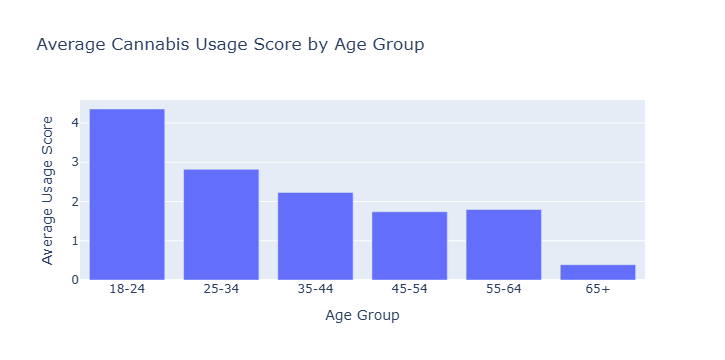

In [22]:
test_data = analysis[analysis["Drug"] == "Cannabis"]
 
fig1 = px.bar(
test_data.groupby("Age Group")["UsageScore"]
.mean()
.reset_index(),
x="Age Group",
y="UsageScore",
title="Average Cannabis Usage Score by Age Group",
labels={
"Age Group": "Age Group",
"UsageScore": "Average Usage Score"
}
)
 
fig1.show()

**What evidence should a viewer obtain from the first figure?**
The first figure shows how drug-use frequency differs across age groups. It helps viewers identify which age groups report higher or lower levels of use for the selected substance.


## 14. Create the second static Plotly figure

The second figure should add different but related evidence rather than repeat the first figure in another style.



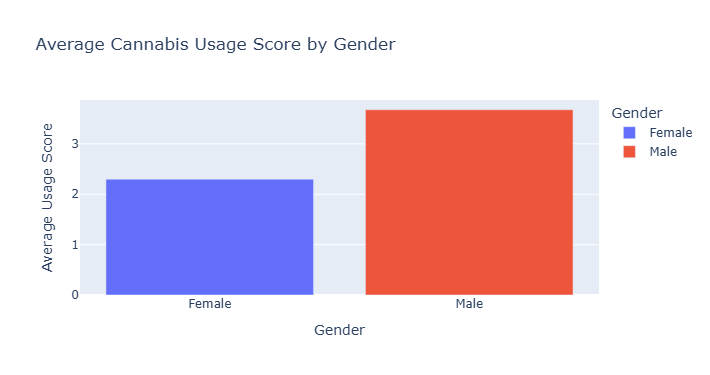

In [24]:
fig2 = px.bar(
test_data.groupby("Gender Label")["UsageScore"]
.mean()
.reset_index(),
x="Gender Label",
y="UsageScore",
color="Gender Label",
title="Average Cannabis Usage Score by Gender",
labels={
"Gender Label": "Gender",
"UsageScore": "Average Usage Score"
}
)
 
fig2.show()

**What does the second figure add to the first figure's evidence?**
The second figure adds a gender-based comparison to the age-based evidence shown in the first figure. Together, the figures help users understand how drug-use patterns vary across both age and gender groups.


## 15. Plan the dashboard



**Complete the dashboard plan before writing the app. Add rows if needed.**

| Component | What it displays or controls | Why it belongs on the dashboard |
|------------|------------|------------|
| Title and introduction | Dashboard purpose and research question | Provides context and explains the goals of the dashboard |
| Interactive control | Dropdown menu used to select a drug | Allows users to compare different substances |
| First figure | Average usage score by age group | Shows how substance use varies across age groups |
| Second figure | Average usage score by gender | Shows how substance use varies by gender |
| Conclusion | Main findings from the dashboard | Helps users interpret the evidence |
| Limitation | Important caution about the data | Encourages responsible interpretation |
Show more lines



## 16. Create reusable figure code

Write a function that accepts the selected control value, filters or summarizes `analysis`, creates both Plotly figures, and returns the figures in a consistent order. Fix axis ranges or category orders when they need to remain stable across selections.



In [32]:
def create_figures(selected_drug):
    filtered = analysis[
        analysis["Drug"] == selected_drug
    ]

    age_order = [
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65+"
    ]

    fig1 = px.bar(
        filtered.groupby("Age Group")["UsageScore"]
        .mean()
        .reset_index(),
        x="Age Group",
        y="UsageScore",
        title=f"Average {selected_drug} Usage Score by Age Group",
        labels={
            "Age Group": "Age Group",
            "UsageScore": "Average Usage Score"
        },
        category_orders={
            "Age Group": age_order
        }
    )

    fig1.update_yaxes(range=[0, 6])

    fig2 = px.bar(
        filtered.groupby("Gender Label")["UsageScore"]
        .mean()
        .reset_index(),
        x="Gender Label",
        y="UsageScore",
        color="Gender Label",
        title=f"Average {selected_drug} Usage Score by Gender",
        labels={
            "Gender Label": "Gender",
            "UsageScore": "Average Usage Score"
        }
    )

    fig2.update_yaxes(range=[0, 6])

    return fig1, fig2

## 17. Build the layout

Create a Dash app and its layout. Include the title, purpose statement, interactive control, two empty `dcc.Graph` components with unique IDs, and short conclusion and limitation statements.



In [33]:
app = Dash(__name__)
 
app.layout = html.Div([
 
html.H1(
"Drug Consumption Dashboard"
),
 
html.P(
"This dashboard explores how reported drug use varies across age groups and gender."
),
 
dcc.Dropdown(
id="drug-dropdown",
options=drug_options,
value="Cannabis",
clearable=False
),
 
dcc.Graph(id="age-graph"),
 
dcc.Graph(id="gender-graph"),
 
html.H3("Conclusion"),
 
html.P(
"Substance-use frequency varies across demographic groups and differs by drug type."
),
 
html.H3("Limitation"),
 
html.P(
"The results are based on self-reported survey responses and may not represent actual consumption behavior."
)
 
])

## 18. Connect the callback

Connect the control's `value` to the `figure` property of both graphs. The callback function should call the reusable figure function and return its two figures in the same order as the two outputs.



In [34]:
@app.callback(
    [
        Output("age-graph", "figure"),
        Output("gender-graph", "figure")
    ],
    Input("drug-dropdown", "value")
)
def update_dashboard(selected_drug):
    fig1, fig2 = create_figures(
        selected_drug
    )

    return fig1, fig2

## 19. Check the callback as a Python function

Call the callback or reusable figure function with at least two valid control values. Confirm that each call returns two Plotly figures without an error.



In [35]:
create_figures("Cannabis")

(Figure({
     'data': [{'hovertemplate': 'Age Group=%{x}<br>Average Usage Score=%{y}<extra></extra>',
               'legendgroup': '',
               'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
               'name': '',
               'orientation': 'v',
               'showlegend': False,
               'textposition': 'auto',
               'type': 'bar',
               'x': array(['18-24', '25-34', '35-44', '45-54', '55-64', '65+'], dtype=object),
               'xaxis': 'x',
               'y': {'bdata': 'SG55xbBsEUDZaJtcko0GQP3oRz/60QFA9DzP8zzP+z+77LLLLrv8PzmO4ziO49g/', 'dtype': 'f8'},
               'yaxis': 'y'}],
     'layout': {'barmode': 'relative',
                'legend': {'tracegroupgap': 0},
                'template': '...',
                'title': {'text': 'Average Cannabis Usage Score by Age Group'},
                'xaxis': {'anchor': 'y',
                          'categoryarray': [18-24, 25-34, 35-44, 45-54, 55-64, 65+],
                          

In [36]:
create_figures("Alcohol")

(Figure({
     'data': [{'hovertemplate': 'Age Group=%{x}<br>Average Usage Score=%{y}<extra></extra>',
               'legendgroup': '',
               'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
               'name': '',
               'orientation': 'v',
               'showlegend': False,
               'textposition': 'auto',
               'type': 'bar',
               'x': array(['18-24', '25-34', '35-44', '45-54', '55-64', '65+'], dtype=object),
               'xaxis': 'x',
               'y': {'bdata': 'C3fH2R+QEkCkK25RR7oSQBrPeMYznhJAmFPwcgpeEkA98sgjjzwSQMdxHMdxHA9A', 'dtype': 'f8'},
               'yaxis': 'y'}],
     'layout': {'barmode': 'relative',
                'legend': {'tracegroupgap': 0},
                'template': '...',
                'title': {'text': 'Average Alcohol Usage Score by Age Group'},
                'xaxis': {'anchor': 'y',
                          'categoryarray': [18-24, 25-34, 35-44, 45-54, 55-64, 65+],
                          '

In [37]:
create_figures("Heroin")

(Figure({
     'data': [{'hovertemplate': 'Age Group=%{x}<br>Average Usage Score=%{y}<extra></extra>',
               'legendgroup': '',
               'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
               'name': '',
               'orientation': 'v',
               'showlegend': False,
               'textposition': 'auto',
               'type': 'bar',
               'x': array(['18-24', '25-34', '35-44', '45-54', '55-64', '65+'], dtype=object),
               'xaxis': 'x',
               'y': {'bdata': 'DMtWYoOS4D/AmAGd+YvZPx3mMIc5zNE/S/cGlIkrzT9FE0000UTDPwAAAAAAAAAA', 'dtype': 'f8'},
               'yaxis': 'y'}],
     'layout': {'barmode': 'relative',
                'legend': {'tracegroupgap': 0},
                'template': '...',
                'title': {'text': 'Average Heroin Usage Score by Age Group'},
                'xaxis': {'anchor': 'y',
                          'categoryarray': [18-24, 25-34, 35-44, 45-54, 55-64, 65+],
                          'c

## 20. Run the dashboard

Run the app in a browser tab. Use a port that is not already occupied by another app, and stop the app before restarting the same code.



In [39]:
if __name__ == "__main__":
    app.run(debug=True, port=8052)

**After testing every control option, what did you revise or confirm about the dashboard's behavior?**
After testing the control options, I confirmed that each drug can be selected from the dropdown and that both charts update to show the selected drug. The age and gender comparisons remain on the same 0–6 usage-score scale, making the results easier to compare.


**Which design choice most improves the dashboard's readability or usefulness?**
The most useful design choice is the interactive drug dropdown because it allows users to examine different substances without needing separate charts for every drug. Keeping the age groups in a consistent order and using the same 0–6 y-axis range also makes comparisons easier.


# Step 6: Conclusion



**State a concise conclusion that directly answers the research question and refers to evidence visible in the dashboard.**
The dashboard shows that reported substance-use frequency varies across age groups and gender, and the pattern differs depending on the substance selected. The age-group chart shows differences in average usage scores among the six age groups, while the gender chart shows differences between male and female respondents. The dropdown allows these patterns to be examined for different substances.


**How does the interactive control help the audience examine the evidence?**
The interactive dropdown allows users to select different substances and immediately see how the average usage score changes across age groups and gender. This makes it easier to explore patterns across multiple drugs without creating a separate dashboard for each substance.


# Step 7: Limitation



**State one important limitation on how the dashboard's evidence should be interpreted.**
One important limitation is that the data are based on self-reported survey responses. Participants may not report their substance use perfectly, so the usage scores should be interpreted as reported behavior rather than a direct measurement of actual consumption. In addition, the dataset may not represent the substance-use behavior of the entire population.


## AI-use reflection



**Describe any AI assistance you used. Identify one suggestion you verified, revised, or rejected. If you did not use AI, state that.**

I used AI to brainstorm the best dataset to use and to make my text answers sound more profesional.

## Submission checklist

Before submitting, confirm that:

- [ ] every prompt has one complete response;
- [ ] all notebook cells run in order without an error;
- [ ] the dashboard opens and every control option works;
- [ ] the two figures use readable titles, labels, categories, and colors;
- [ ] comparable views retain stable axes or category orders when needed;
- [ ] the dataset source is cited and the required data file accompanies the submission;
- [ ] the notebook and dashboard code are organized and readable;
- [ ] the conclusion and limitation are supported by the displayed evidence; and
- [ ] the work is submitted by the deadline.

